In [60]:
from typing import Literal
import os

from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.graph import END, START, StateGraph, MessagesState
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import ToolNode

# --- WEATHER TOOL ---
@tool
def get_weather(location: str) -> str:
    """Call the get the current weather"""
    print(f"---You are querying weather info of {location}")
    if location.lower() in ["munich"]:
        return "It's 15 degrees Celsius in Munich."
    else:
        return "It's 32 degress Celcisu and sunny."

# Create a model and bind the tool so the llm knows it can call "get_weather"
llm = ChatOpenAI(model="deepseek-chat", api_key=os.getenv("DEEPSEEK_API_KEY"), base_url="https://api.deepseek.com", temperature=0)

llm_with_weather_tools = llm.bind_tools([get_weather])

In [61]:
from langchain_core.messages import SystemMessage

def call_model(state: MessagesState):
    """Call the LLM with the conversation so far."""
    messages = state["messages"]
    # 加上 system prompt 指示翻译 ↓
    system_message = SystemMessage(content="""
你是一个天气助手。
在调用 get_weather 工具时，请将城市名翻译成英文。
例如：慕尼黑 → Munich，北京 → Beijing
""")
    
    response = llm_with_weather_tools.invoke([system_message] + messages)
    return {"messages": [response]}

In [62]:
def should_continue(state: MessagesState) -> Literal["tools", END]:
    """
    If there's a tool call requested, go to "tools", else end.
    """
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [63]:
weather_workflow = StateGraph(MessagesState)

tool_node = ToolNode([get_weather])

weather_workflow.add_node("agent", call_model)
weather_workflow.add_node("tools", tool_node)

weather_workflow.add_edge(START, "agent") # 等效于 weather_workflow.set_entry_point("agent")
weather_workflow.add_conditional_edges("agent", should_continue)
weather_workflow.add_edge("tools", "agent")

weather_agent_graph = weather_workflow.compile(name="weather_agent")


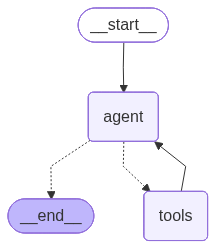

In [64]:
from IPython.display import Image, display

display(Image(weather_agent_graph.get_graph().draw_mermaid_png()))

In [ ]:
from langgraph_supervisor import create_supervisor

supervisor_workflow = create_supervisor(
    agents=[weather_agent_graph],
    model=llm,
    prompt=(
        "You are a supervisor managing a weather agent. "
        "For any weather-related questions, call the 'weather_agent' to handle it. For the city name, please translate it to English"
    ),
    output_mode="full_history", # output_mode="full_history"
    supervisor_name="supervisor_agent"
)

supervisor_app = supervisor_workflow.compile()

In [66]:
supervisor_app.invoke(
    {"messages": [HumanMessage(content="Hello there, how are you?")]}
)

{'messages': [HumanMessage(content='Hello there, how are you?', additional_kwargs={}, response_metadata={}, id='321a9ce0-329e-4a98-aeab-f2381858b67c'),
  AIMessage(content="Hello! I'm doing well, thank you for asking! I'm here to help you with any weather-related questions you might have. If you need information about weather conditions, forecasts, or anything else weather-related, just let me know and I'll connect you with the weather specialist!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 333, 'total_tokens': 390, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 320}, 'prompt_cache_hit_tokens': 320, 'prompt_cache_miss_tokens': 13}, 'model_provider': 'openai', 'model_name': 'deepseek-chat', 'system_fingerprint': 'fp_eaab8d114b_prod0820_fp8_kvcache', 'id': '8b161336-1ad3-4d1a-a10f-436beb2e2980', 'finish_reason': 'stop', 'logprobs': None}, name='supervisor_agent', i

In [67]:
munich_result = supervisor_app.invoke(
    {"messages": [HumanMessage(content="How is the weather in Munich?")]}
)

---You are querying weather info of Munich


In [68]:
for msg in munich_result["messages"]:
    # print(msg.pretty_print())
    print(f"Type: {type(msg).__name__}")
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        print(f"Tool Calls: {msg.tool_calls}")
        for tc in msg.tool_calls:
            print(f"  - Name: {tc['name']}")
            print(f"  - Args: {tc['args']}")  # ← 这里能看到参数
            print(f"  - ID: {tc['id']}")

Type: HumanMessage
Type: AIMessage
Tool Calls: [{'name': 'transfer_to_weather_agent', 'args': {}, 'id': 'call_00_NSgPda5MFrLyIaWjEzFxGtFK', 'type': 'tool_call'}]
  - Name: transfer_to_weather_agent
  - Args: {}
  - ID: call_00_NSgPda5MFrLyIaWjEzFxGtFK
Type: ToolMessage
Type: AIMessage
Type: AIMessage
Tool Calls: [{'name': 'transfer_back_to_supervisor_agent', 'args': {}, 'id': '6f9355d8-0d1b-4bc1-bf25-7e87c0af34af', 'type': 'tool_call'}]
  - Name: transfer_back_to_supervisor_agent
  - Args: {}
  - ID: 6f9355d8-0d1b-4bc1-bf25-7e87c0af34af
Type: ToolMessage
Type: AIMessage


In [69]:
result = supervisor_app.invoke(
    {"messages": [HumanMessage(content="慕尼黑明天天气怎么样?")]}
)

---You are querying weather info of Munich


In [70]:
# 详细查看每条消息
for msg in result["messages"]:
    msg.pretty_print()
    # print(f"Type: {type(msg).__name__}")
    # if hasattr(msg, 'tool_calls') and msg.tool_calls:
    #     print(f"Tool Calls: {msg.tool_calls}")
    #     for tc in msg.tool_calls:
    #         print(f"  - Name: {tc['name']}")
    #         print(f"  - Args: {tc['args']}")  # ← 这里能看到参数
    #         print(f"  - ID: {tc['id']}")
    # print("---")

================================ Human Message =================================

慕尼黑明天天气怎么样?
================================== Ai Message ==================================
Name: supervisor_agent

我来帮您查询慕尼黑明天的天气情况。
Tool Calls:
  transfer_to_weather_agent (call_00_MsHblGNwn93LS5DHhCtnvOr5)
 Call ID: call_00_MsHblGNwn93LS5DHhCtnvOr5
  Args:
================================= Tool Message =================================
Name: transfer_to_weather_agent

Successfully transferred to weather_agent
================================== Ai Message ==================================

根据查询结果，慕尼黑当前的气温是15摄氏度。不过，我需要向您说明一下，我查询到的是当前天气情况，而不是明天的天气预报。

如果您想了解慕尼黑明天的具体天气预报（包括温度、降水概率、风力等信息），建议您：
1. 查看专门的天气预报网站或应用
2. 或者我可以帮您查询其他天气服务（如果有相关工具的话）

当前我只能提供慕尼黑的实时天气信息，显示温度为15°C。
================================== Ai Message ==================================
Name: weather_agent

Transferring back to supervisor_agent
Tool Calls:
  transfer_back_to_supervisor_agent (9f9f4638-ee56-48e5-8486-9a22564f6e97)
 Call ID: 9f